In [1]:
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP245"

In [2]:
varname='wap'

In [3]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    # "piControl": {"project": "CMIP",        "scenario": "piControl"},
    # "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    # "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    # "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [4]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/gws/ssde/j25b/impose/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "Amon" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=50))



In [5]:
# ================================================================
# MAIN PROCESSING LOOP - Tropical circulation metrics
# Following Bony et al. (2013) for tropical overturning circulation
# ================================================================

import pandas as pd
import xarray as xr
import numpy as np

var = {}
var_by_year = {}
data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}
all_results = {}

# Tropical bounds
trop_lat_min = -30
trop_lat_max = 30

# Pressure level
target_plev = 50000  # 500 hPa in Pa

for model_name, model_meta in MODELS.items():

    components_by_exp = {}
    seasonal_data = {}

    # ----------------------------
    # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
    # ----------------------------
    for exp, meta in EXPERIMENTS.items():

        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_wap = make_base("wap")
        
        ####### Handle ALTERNATE base paths ######
        ds_wap = load_model_data_alt_path(base_wap, meta["project"], 
                                          model_meta["institution"], 
                                          model_name, meta["scenario"], 
                                          ensemble, model_meta["grid"], mf, "wap")
        
        # Roll and regrid
        ds_wap = roll_and_regrid(ds_wap)
        
        print(f"  [{model_name}] {exp}: wap loaded {ds_wap.sizes['time']} months "
              f"({ds_wap.time.values[0]} → {ds_wap.time.values[-1]})")

        # Extract omega (wap) variable
        if isinstance(ds_wap, xr.Dataset):
            omega = ds_wap['wap']
        else:
            omega = ds_wap
        
        # Select 500 hPa level and tropical region
        omega_500 = omega.sel(plev=target_plev, method='nearest')
        omega_trop = omega_500.sel(lat=slice(trop_lat_min, trop_lat_max))
        
        var[exp] = omega_trop
    
    # ----------------------------
    # 2) Compute upward and downward circulation
    # ----------------------------
    for exp, omega_trop in var.items():
        
        # Separate upward (ω < 0) and downward (ω > 0) motion
        # In pressure coordinates: negative ω = upward, positive ω = downward
        
        # Upward motion (negative omega)
        omega_up = omega_trop.where(omega_trop < 0, 0)
        
        # Downward motion (positive omega)
        omega_down = omega_trop.where(omega_trop > 0, 0)
        
        # Load land-sea mask if available
        # If you have a land mask:
        # land_mask = ...  # Should be regridded to same grid
        # omega_land = omega_trop.where(land_mask == 1)
        # omega_ocean = omega_trop.where(land_mask == 0)
        
        # For now, compute for land+ocean combined
        # Monthly mean tropical averages
        omega_up_mean = omega_up.mean(dim=("lat", "lon"))
        omega_down_mean = omega_down.mean(dim=("lat", "lon"))
        
        # Circulation strength = |upward| - |downward| 
        # or simply: mean(upward) - mean(downward)
        circulation_strength = omega_down_mean - omega_up_mean
        
        # Store time series
        data_by_experiment[exp].append({
            'omega_up': omega_up_mean,
            'omega_down': omega_down_mean,
            'circulation': circulation_strength,
            'model': model_name
        })

/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] G6sulfur: wap loaded 972 months (2020-01-16 00:00:00 → 2100-12-16 00:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] SSP245: wap loaded 1032 months (2015-01-16 00:00:00 → 2100-12-16 00:00:00)
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
Alt path is: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  → Using downloaded files at: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] G6sulfur: wap loaded 1032 months (2015-01-16 12:00:00 → 2100-12-16 12:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] SSP245: wap loaded 1032 months (2015-01-16 12:00:00 → 2100-12-16 12:00:00)
/badc/cmip6/data/CMIP6/Ge

In [6]:
import dask

data_by_experiment_computed = dask.compute(data_by_experiment)[0]

In [7]:
# --- Define common year range ---
common_years = np.arange(2021, 2101)

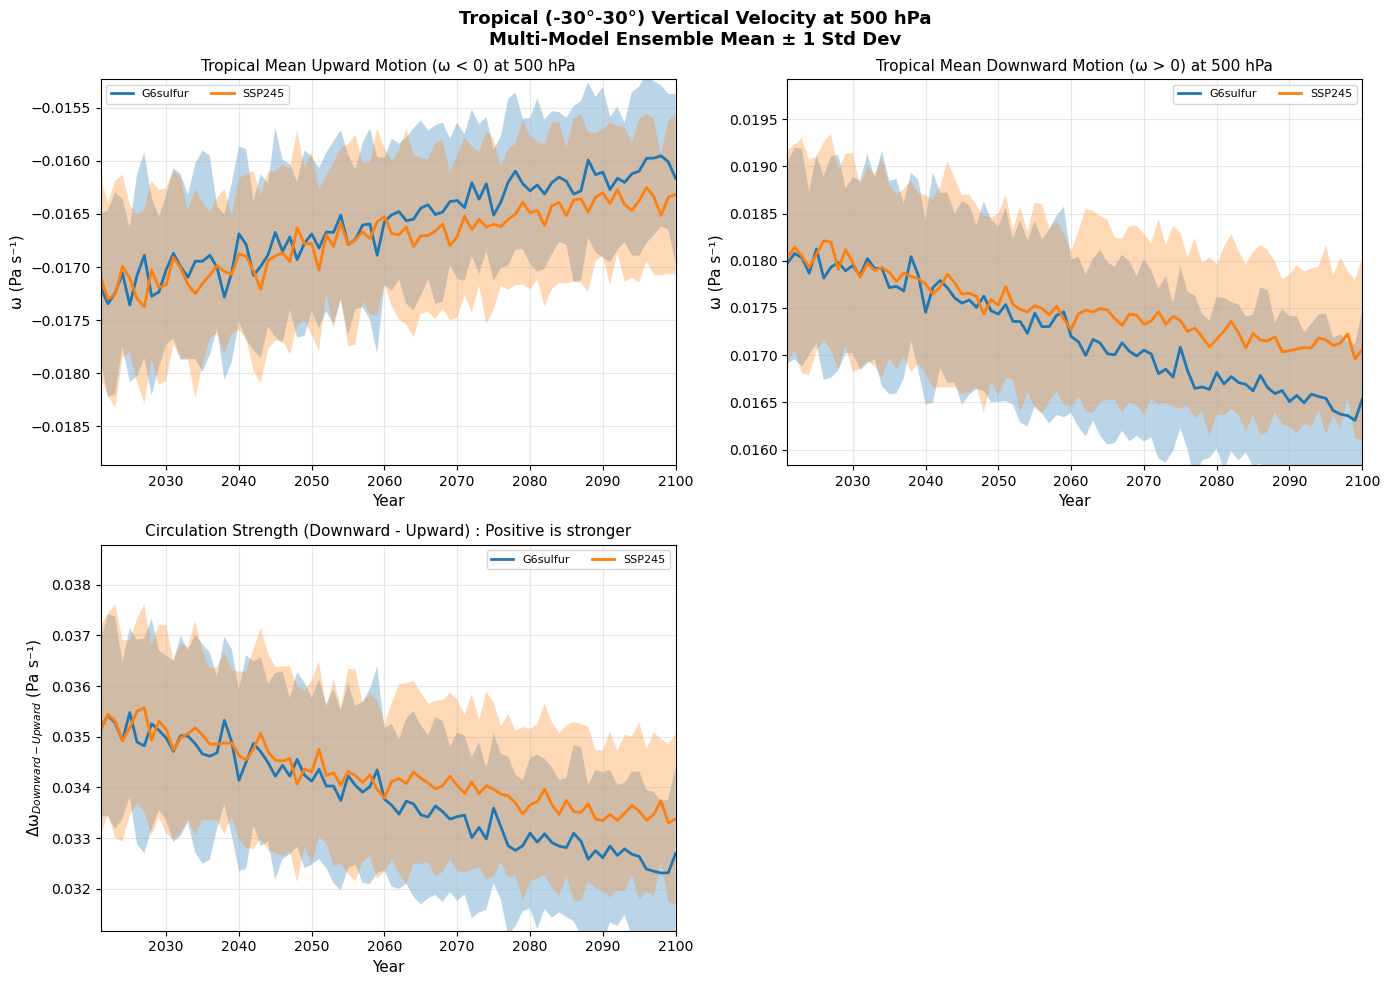

In [11]:
# --- Create figure with subplots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = ['omega_up', 'omega_down', 'circulation']
titles = [
    'Tropical Mean Upward Motion (ω < 0) at 500 hPa',
    'Tropical Mean Downward Motion (ω > 0) at 500 hPa',
    'Circulation Strength (Downward - Upward) : Positive is stronger',
]
ylabels = [
    'ω (Pa s⁻¹)',
    'ω (Pa s⁻¹)',
    'Δω$_{Downward - Upward}$ (Pa s⁻¹)',
]

# --- Plot ensemble mean and spread for each metric ---
for idx, (metric, title, ylabel) in enumerate(zip(metrics, titles, ylabels)):
    
    ax = axes[idx]
    ensemble_means = {}
    
    for exp, meta in EXPERIMENTS.items():
        
        all_models = data_by_experiment_computed[exp]
        
        if len(all_models) == 0:
            continue
        
        # Align all models to common year grid
        aligned_data = []
        for model_dict in all_models:
            ts = model_dict[metric]
            
            # Extract year from time coordinate (handles cftime objects)
            # Convert to annual mean using xarray (handles cftime safely)
            annual_ts = ts.groupby("time.year").mean("time")
            
            # Convert to pandas Series with unique year index
            series = pd.Series(
                annual_ts.values,
                index=annual_ts.year.values
            )
            # Reindex to common year axis
            aligned = series.reindex(common_years)
            aligned_data.append(aligned.values)
        
        if len(aligned_data) == 0:
            continue
        
        # Stack into 2D array (models x years)
        model_data = np.array(aligned_data)
        v1 = float(np.nanmin(model_data))
        v2 = float(np.nanmax(model_data))
        vmin, vmax = min(v1, v2), max(v1, v2)
        
        # Calculate ensemble mean and spread
        ensemble_mean = np.nanmean(model_data, axis=0)
        ensemble_std = np.nanstd(model_data, axis=0)
        
        # Valid data mask
        valid_mask = ~np.isnan(ensemble_mean)
        
        # Save ensemble mean
        ensemble_means[exp] = ensemble_mean
        
        # Plot
        # Plot
        line_color = meta.get("color", None)
        line, = ax.plot(
            common_years[valid_mask],
            ensemble_mean[valid_mask],
            label=exp,
            color=line_color,
            linewidth=2,
        )
        
        # Shaded spread (±1 std)
        ax.fill_between(
            common_years[valid_mask],
            (ensemble_mean - ensemble_std)[valid_mask],
            (ensemble_mean + ensemble_std)[valid_mask],
            facecolor=line.get_color(),  # always matches the line
            alpha=0.3,
            edgecolor='none',
        )
    
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel("Year", fontsize=11)
    ax.legend(ncol=2, fontsize=8, loc="best")
    ax.set_title(title, fontsize=11)
    ax.set_xlim(2021, 2100)
    ax.set_ylim(vmin, vmax)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)

# Remove empty subplot
axes[3].axis('off')

plt.suptitle(
    f"Tropical ({trop_lat_min}°-{trop_lat_max}°) Vertical Velocity at 500 hPa\n"
    "Multi-Model Ensemble Mean ± 1 Std Dev",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()

# Save
fig_directory = "./"
figname = "Figure_TropicalCirculation_500hPa_EnsembleMean"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')

plt.show()

In [9]:
int(common_years[-1])

2100

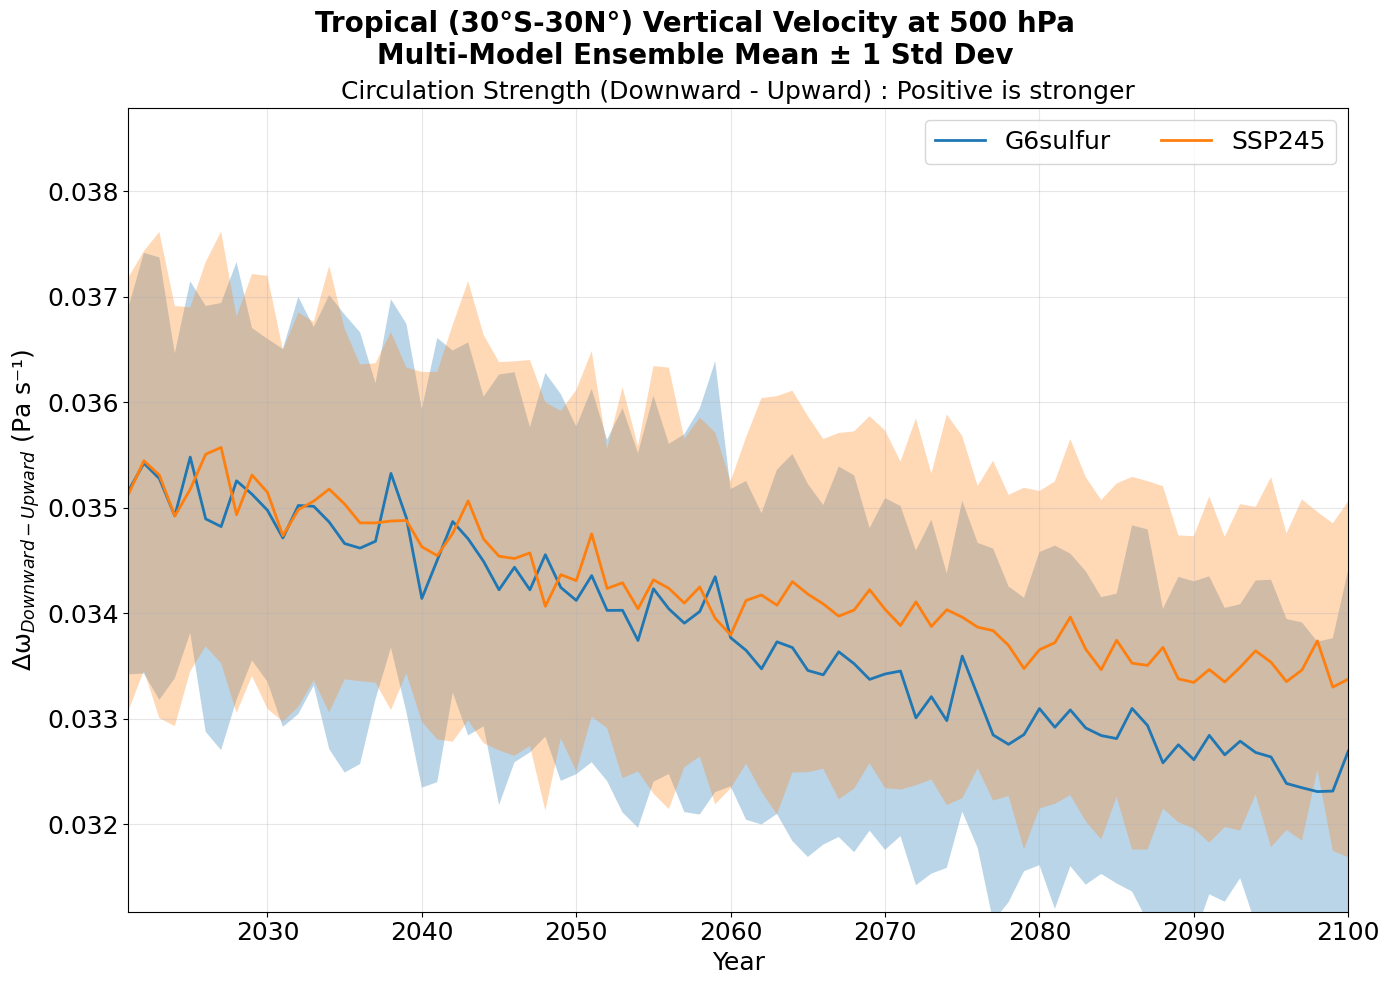

In [21]:
# --- Create figure with subplots ---
fig, axes = plt.subplots(figsize=(14, 10))
# axes = axes.flatten()

metrics = ['circulation']
titles = [
    'Circulation Strength (Downward - Upward) : Positive is stronger',
]
ylabels = [
    'Δω$_{Downward - Upward}$ (Pa s⁻¹)',
]

# --- Plot ensemble mean and spread for each metric ---
for idx, (metric, title, ylabel) in enumerate(zip(metrics, titles, ylabels)):
    
    ax = axes
    ensemble_means = {}
    
    for exp, meta in EXPERIMENTS.items():
        
        all_models = data_by_experiment_computed[exp]
        
        if len(all_models) == 0:
            continue
        
        # Align all models to common year grid
        aligned_data = []
        for model_dict in all_models:
            ts = model_dict[metric]
            
            # Extract year from time coordinate (handles cftime objects)
            # Convert to annual mean using xarray (handles cftime safely)
            annual_ts = ts.groupby("time.year").mean("time")
            
            # Convert to pandas Series with unique year index
            series = pd.Series(
                annual_ts.values,
                index=annual_ts.year.values
            )
            # Reindex to common year axis
            aligned = series.reindex(common_years)
            aligned_data.append(aligned.values)
        
        if len(aligned_data) == 0:
            continue
        
        # Stack into 2D array (models x years)
        model_data = np.array(aligned_data)
        v1 = float(np.nanmin(model_data))
        v2 = float(np.nanmax(model_data))
        vmin, vmax = min(v1, v2), max(v1, v2)
        
        # Calculate ensemble mean and spread
        ensemble_mean = np.nanmean(model_data, axis=0)
        ensemble_std = np.nanstd(model_data, axis=0)
        
        # Valid data mask
        valid_mask = ~np.isnan(ensemble_mean)
        
        # Save ensemble mean
        ensemble_means[exp] = ensemble_mean
        
        # Plot
        # Plot
        line_color = meta.get("color", None)
        line, = ax.plot(
            common_years[valid_mask],
            ensemble_mean[valid_mask],
            label=exp,
            color=line_color,
            linewidth=2,
        )
        
        # Shaded spread (±1 std)
        ax.fill_between(
            common_years[valid_mask],
            (ensemble_mean - ensemble_std)[valid_mask],
            (ensemble_mean + ensemble_std)[valid_mask],
            facecolor=line.get_color(),  # always matches the line
            alpha=0.3,
            edgecolor='none',
        )
    
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_xlabel("Year", fontsize=18)
    ax.legend(ncol=2, fontsize=18, loc="best")
    ax.set_title(title, fontsize=18)
    ax.set_xlim(2021, 2100)
    ax.set_ylim(vmin, vmax)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.tick_params(axis='both', labelsize=18)

# # Remove empty subplot
# axes[3].axis('off')

plt.suptitle(
    f"Tropical ({trop_lat_max}°S-{trop_lat_max}N°) Vertical Velocity at 500 hPa\n"
    "Multi-Model Ensemble Mean ± 1 Std Dev",
    fontsize=20, fontweight='bold'
)
plt.tight_layout()

# Save
fig_directory = "./"
figname = "Figure_TropicalCirculation_500hPa_EnsembleMean_II"
plt.savefig(f"{fig_directory}/{figname}.png", format="png", bbox_inches='tight')

plt.show()